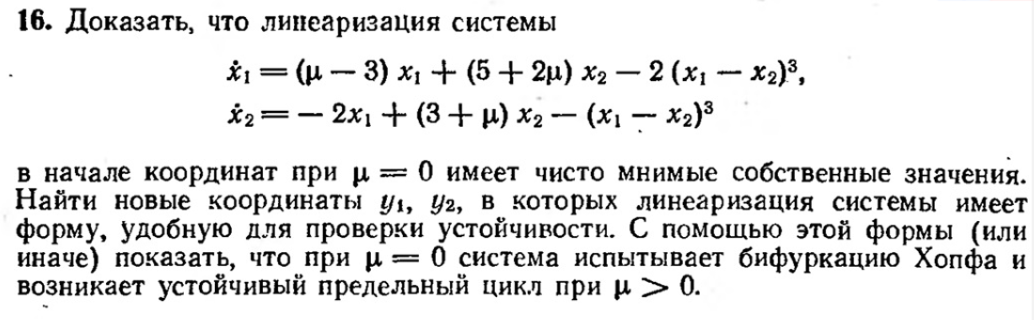

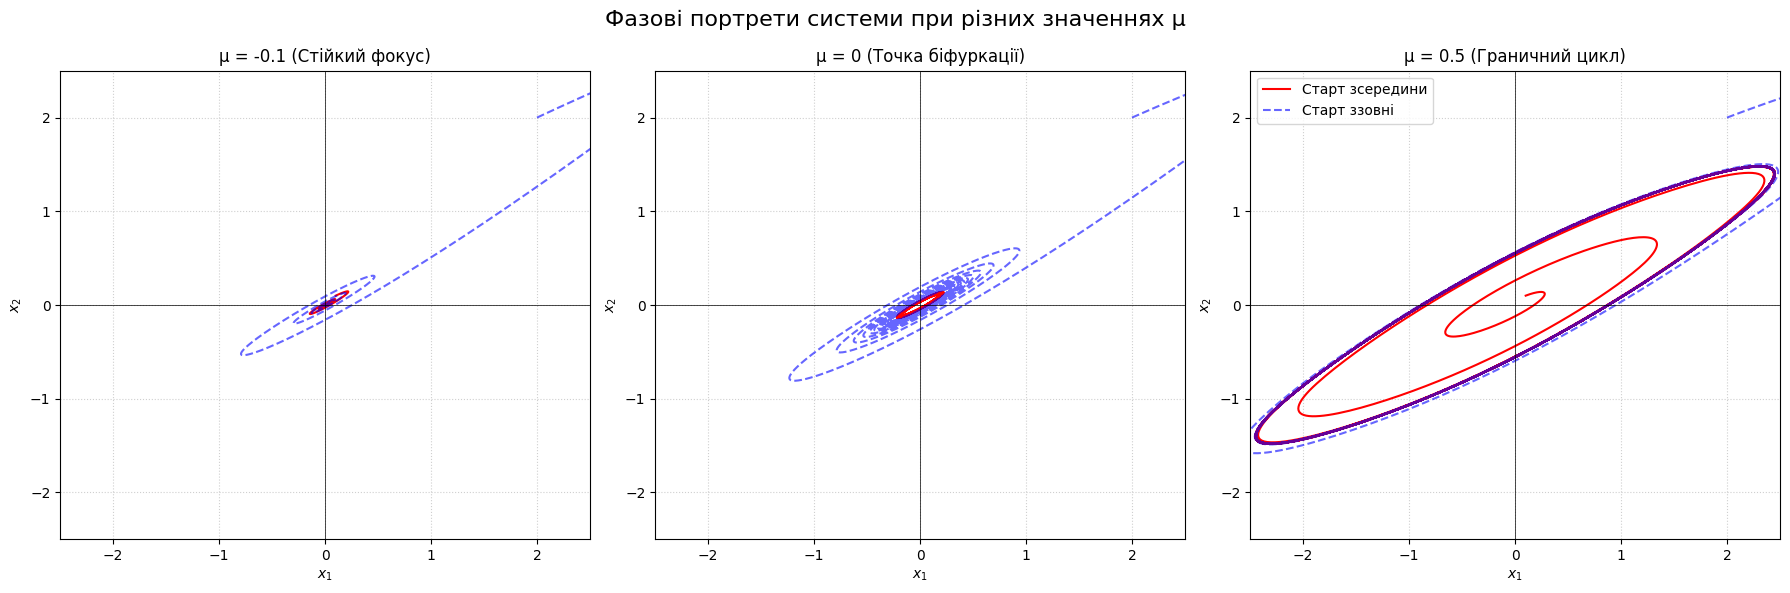

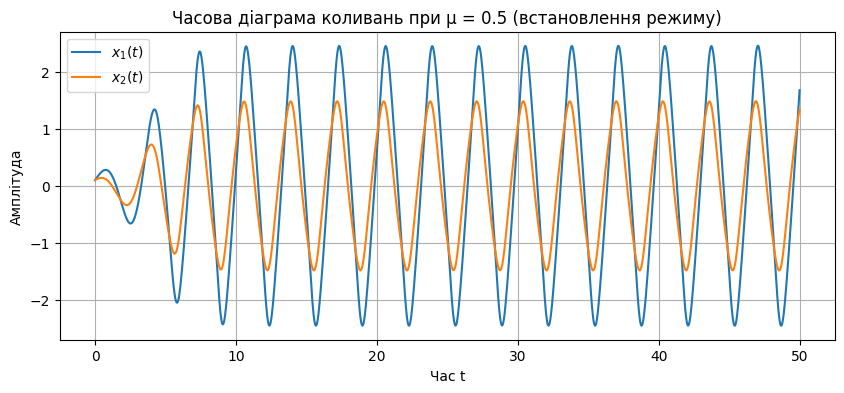

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Визначення системи рівнянь
def system_equations(t, state, mu):
    x1, x2 = state

    # Задана система
    dx1 = (mu - 3) * x1 + (5 + 2 * mu) * x2 - 2 * (x1 - x2)**3
    dx2 = -2 * x1 + (3 + mu) * x2 - (x1 - x2)**3

    return [dx1, dx2]

# Параметри моделювання
t_span = (0, 100)  # Час моделювання
t_eval = np.linspace(0, 100, 5000) # Точки для графіків

# Список випадків для mu
mu_values = [-0.1, 0, 0.5]
titles = [
    "µ = -0.1 (Стійкий фокус)",
    "µ = 0 (Точка біфуркації)",
    "µ = 0.5 (Граничний цикл)"
]

plt.figure(figsize=(18, 6))

for i, mu in enumerate(mu_values):
    ax = plt.subplot(1, 3, i + 1)

    # Траєкторія, що стартує близько до центру (червона)
    sol_inner = solve_ivp(system_equations, t_span, [0.1, 0.1], args=(mu,), t_eval=t_eval)
    ax.plot(sol_inner.y[0], sol_inner.y[1], 'r-', label='Старт зсередини', linewidth=1.5)

    # Траєкторія, що стартує здалеку (синя)
    sol_outer = solve_ivp(system_equations, t_span, [2.0, 2.0], args=(mu,), t_eval=t_eval)
    ax.plot(sol_outer.y[0], sol_outer.y[1], 'b--', label='Старт ззовні', alpha=0.6)

    # Оформлення графіків
    ax.set_title(titles[i])
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

    # Обмеження осей для кращої візуалізації
    limit = 2.5
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)

    if i == 2:
        ax.legend()

plt.suptitle("Фазові портрети системи при різних значеннях µ", fontsize=16)
plt.tight_layout()
plt.show()

# Додатково: графік часової залежності для µ = 0.5, щоб показати коливання
mu_cycle = 0.5
sol_cycle = solve_ivp(system_equations, (0, 50), [0.1, 0.1], args=(mu_cycle,), t_eval=np.linspace(0, 50, 2000))

plt.figure(figsize=(10, 4))
plt.plot(sol_cycle.t, sol_cycle.y[0], label='$x_1(t)$')
plt.plot(sol_cycle.t, sol_cycle.y[1], label='$x_2(t)$')
plt.title(f"Часова діаграма коливань при µ = {mu_cycle} (встановлення режиму)")
plt.xlabel("Час t")
plt.ylabel("Амплітуда")
plt.grid(True)
plt.legend()
plt.show()